<a href="https://colab.research.google.com/github/BhagyashreeMohalkar/ADS_Lab_Assignments/blob/main/Object_Detection_using_YOLO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q ultralytics kaggle opencv-python matplotlib pandas pyyaml

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.1/78.1 kB 4.4 MB/s eta 0:00:00


In [2]:
import os
import cv2
import yaml
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from collections import Counter

from ultralytics import YOLO

print("Libraries imported successfully!")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Libraries imported successfully!


In [3]:
# ============================================================
# CELL 3: Kaggle API Key Input
# ============================================================

from getpass import getpass
import os

# Create a secure text box
kaggle_api_key = getpass("🔑 Enter your Kaggle API Key: ")

# Set Kaggle environment variables
os.environ["KAGGLE_API_TOKEN"] = kaggle_api_key

print("✅ Kaggle API key entered successfully!")

🔑 Enter your Kaggle API Key: ··········
✅ Kaggle API key entered successfully!


In [4]:
# ============================================================
# CELL 4: Test Kaggle API
# ============================================================

!kaggle datasets list -s "indian driving dataset" | head -10

ref                                                                title                                                      size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-----------------------------------------------------------------  --------------------------------------------------  -----------  --------------------------  -------------  ---------  ---------------  
mitanshuchakrawarty/new-idd-dataset                                Indian Driving Dataset (IDD Dataset)                 2995503490  2023-03-23 15:32:48.673000           2070         19  0.625            
redzapdos123/indian-driving-dataset-detections-yolov11             Indian Driving Dataset-Detections (YOLOv11)         21978256293  2025-08-11 17:55:38.503000           5816         13  0.9375           
manjotpahwa/indian-driving-dataset                                 Indian Driving Dataset                               5920724657  2019-11-17 13:37:55.133000           1402         16

In [5]:
# ============================================================
# CELL 5: Download Dataset
# ============================================================

!mkdir -p /content/Smart_Traffic_Monitoring/dataset

!kaggle datasets download \
    -d redzapdos123/indian-driving-dataset-detections-yolov11 \
    -p /content/Smart_Traffic_Monitoring/dataset

print("✅ Dataset downloaded successfully!")

Dataset URL: https://www.kaggle.com/datasets/redzapdos123/indian-driving-dataset-detections-yolov11
License(s): CC-BY-NC-SA-4.0
100% 20.5G/20.5G [09:09<00:00, 40.0MB/s]

✅ Dataset downloaded successfully!


In [7]:
# ============================================================
# CELL 6: CHECK GPU
# ============================================================

import torch

print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("✅ GPU is available!")
    print("GPU Name:", torch.cuda.get_device_name(0))

    gpu_memory = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    print(f"GPU Memory: {gpu_memory:.2f} GB")

    print("CUDA Version:", torch.version.cuda)

else:
    print("❌ GPU is NOT available.")
    print("Go to: Runtime → Change runtime type → Hardware accelerator → GPU")

PyTorch Version: 2.11.0+cu128
CUDA Available: True
✅ GPU is available!
GPU Name: Tesla T4
GPU Memory: 14.56 GB
CUDA Version: 12.8


In [8]:
# ============================================================
# CELL 7: INITIALIZE GPU
# ============================================================

if torch.cuda.is_available():

    DEVICE = torch.device("cuda:0")

    # Clear unused GPU memory
    torch.cuda.empty_cache()

    print("🚀 GPU initialized successfully!")
    print("Using device:", DEVICE)
    print("GPU:", torch.cuda.get_device_name(0))

else:

    DEVICE = torch.device("cpu")

    print("⚠️ Using CPU:", DEVICE)

🚀 GPU initialized successfully!
Using device: cuda:0
GPU: Tesla T4


In [9]:
# ============================================================
# CELL 8: GPU MEMORY STATUS
# ============================================================

if torch.cuda.is_available():

    allocated = torch.cuda.memory_allocated(0) / (1024**3)
    reserved = torch.cuda.memory_reserved(0) / (1024**3)

    print(f"GPU Memory Allocated: {allocated:.2f} GB")
    print(f"GPU Memory Reserved:  {reserved:.2f} GB")

else:

    print("GPU not available.")

GPU Memory Allocated: 0.00 GB
GPU Memory Reserved:  0.00 GB


In [10]:
# ============================================================
# CELL 9: EXTRACT KAGGLE DATASET
# ============================================================

import os
import zipfile
from pathlib import Path

DATASET_DIR = "/content/Smart_Traffic_Monitoring/dataset"

zip_files = list(Path(DATASET_DIR).glob("*.zip"))

print("ZIP files found:")

for file in zip_files:
    print("📦", file.name)

if not zip_files:
    print("❌ No ZIP file found. Check Cell 5.")

else:
    for zip_file in zip_files:

        print(f"\nExtracting {zip_file.name}...")

        with zipfile.ZipFile(zip_file, "r") as zip_ref:
            zip_ref.extractall(DATASET_DIR)

    print("\n✅ Dataset extracted successfully!")

ZIP files found:
📦 indian-driving-dataset-detections-yolov11.zip

Extracting indian-driving-dataset-detections-yolov11.zip...

✅ Dataset extracted successfully!


In [11]:
# ============================================================
# CELL 10: INSPECT DATASET STRUCTURE
# ============================================================

dataset_path = Path(DATASET_DIR)

print("Dataset structure:\n")

for root, dirs, files in os.walk(dataset_path):

    level = root.replace(
        str(dataset_path), ""
    ).count(os.sep)

    if level <= 3:

        indent = "    " * level

        print(
            f"{indent}📁 {os.path.basename(root)}/"
        )

        for file in files[:10]:
            print(
                f"{indent}    📄 {file}"
            )

Dataset structure:

📁 dataset/
    📄 indian-driving-dataset-detections-yolov11.zip
    📁 IDDDetectionsYOLODataset/
        📄 license.md
        📄 ReadMe.md
        📄 data.yaml
        📁 val/
            📁 images/
                📄 BLR-2018-05-03_14-39-45_sideRight_right_0002940.jpg
                📄 BLR-2018-05-11_13-53-01_sideLeft_right_0000150.jpg
                📄 BLR-2018-05-03_14-26-52_sideRight_right_0003146.jpg
                📄 BLR-2018-04-19_18-06-55_frontFar_001224_r.jpg
                📄 BLR-2018-06-05_08-50-18_frontNear_001266_r.jpg
                📄 BLR-2018-05-11_14-09-20_sideRight_right_0000555.jpg
                📄 BLR-2018-05-22_13-21-45_frontNear_0001725.jpg
                📄 BLR-2018-05-22_12-24-44_sideRight_000654_r.jpg
                📄 BLR-2018-04-16_15-54-27_frontFar_0014580.jpg
                📄 BLR-2018-04-19_17-56-55_frontFar_0009540.jpg
            📁 labels/
                📄 BLR-2018-05-22_13-21-45_frontNear_0000780.txt
                📄 BLR-2018-06-20-07-01

In [12]:
# ============================================================
# CELL 11: FIND DATA.YAML
# ============================================================

yaml_files = list(
    dataset_path.rglob("*.yaml")
)

print("YAML files found:\n")

for yaml_file in yaml_files:
    print("📄", yaml_file)

if len(yaml_files) == 0:

    print("\n❌ No YAML file found.")

else:

    print(
        f"\n✅ Found {len(yaml_files)} YAML file(s)."
    )

YAML files found:

📄 /content/Smart_Traffic_Monitoring/dataset/IDDDetectionsYOLODataset/data.yaml

✅ Found 1 YAML file(s).


In [16]:
# ============================================================
# CELL 12: SET DATASET YAML PATH
# ============================================================

if not yaml_files:

    raise FileNotFoundError(
        "data.yaml was not found."
    )

DATA_YAML = str(yaml_files[0])

print("Dataset configuration file:")
print(DATA_YAML)

Dataset configuration file:
/content/Smart_Traffic_Monitoring/dataset/IDDDetectionsYOLODataset/data.yaml


In [17]:
# ============================================================
# CELL 13: READ DATASET CONFIGURATION
# ============================================================

import yaml

with open(DATA_YAML, "r") as file:
    data_config = yaml.safe_load(file)

print("========== DATASET CONFIGURATION ==========\n")

for key, value in data_config.items():
    print(f"{key}: {value}")

print("\n===========================================")

========== DATASET CONFIGURATION ==========

path: IDDDetectionsYOLODataset/
names: ['animal', 'autorickshaw', 'bicycle', 'bus', 'car', 'caravan', 'motorcycle', 'person', 'rider', 'traffic light', 'traffic sign', 'trailer', 'train', 'truck', 'vehicle fallback']
nc: 15
test: test/images
train: train/images
val: val/images



In [18]:
# ============================================================
# CELL 14: DISPLAY DATASET CLASSES
# ============================================================

class_names = data_config["names"]

print("Number of classes:", len(class_names))
print("\nClasses:\n")

if isinstance(class_names, dict):

    for class_id, class_name in class_names.items():
        print(f"{class_id}: {class_name}")

else:

    for class_id, class_name in enumerate(class_names):
        print(f"{class_id}: {class_name}")

Number of classes: 15

Classes:

0: animal
1: autorickshaw
2: bicycle
3: bus
4: car
5: caravan
6: motorcycle
7: person
8: rider
9: traffic light
10: traffic sign
11: trailer
12: train
13: truck
14: vehicle fallback


In [19]:
# ============================================================
# CELL 15: COUNT DATASET IMAGES
# ============================================================

image_extensions = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}

image_files = [
    file
    for file in dataset_path.rglob("*")
    if file.is_file()
    and file.suffix.lower() in image_extensions
]

print("Total images:", len(image_files))

Total images: 41962


In [20]:
# ============================================================
# CELL 16: TRAIN / VALIDATION / TEST IMAGE COUNTS
# ============================================================

for split in ["train", "valid", "val", "test"]:

    split_images = []

    for folder in dataset_path.rglob(split):

        if folder.is_dir():

            split_images.extend([
                file
                for file in folder.rglob("*")
                if file.is_file()
                and file.suffix.lower() in image_extensions
            ])

    if split_images:

        print(
            f"{split.upper():<8}: "
            f"{len(split_images)} images"
        )

TRAIN   : 33569 images
VAL     : 4196 images
TEST    : 4197 images


In [21]:
# ============================================================
# CELL 17: COUNT YOLO ANNOTATIONS
# ============================================================

label_files = [
    file
    for file in dataset_path.rglob("*.txt")
    if file.is_file()
]

print(
    "Total annotation files:",
    len(label_files)
)

Total annotation files: 41962


In [22]:
# ============================================================
# CELL 18: FIND TRAINING IMAGES
# ============================================================

train_images = []

for folder in dataset_path.rglob("train"):

    if folder.is_dir():

        train_images.extend([
            file
            for file in folder.rglob("*")
            if file.is_file()
            and file.suffix.lower() in image_extensions
        ])

print(
    "Training images found:",
    len(train_images)
)

if len(train_images) == 0:

    raise FileNotFoundError(
        "No training images found."
    )

Training images found: 33569


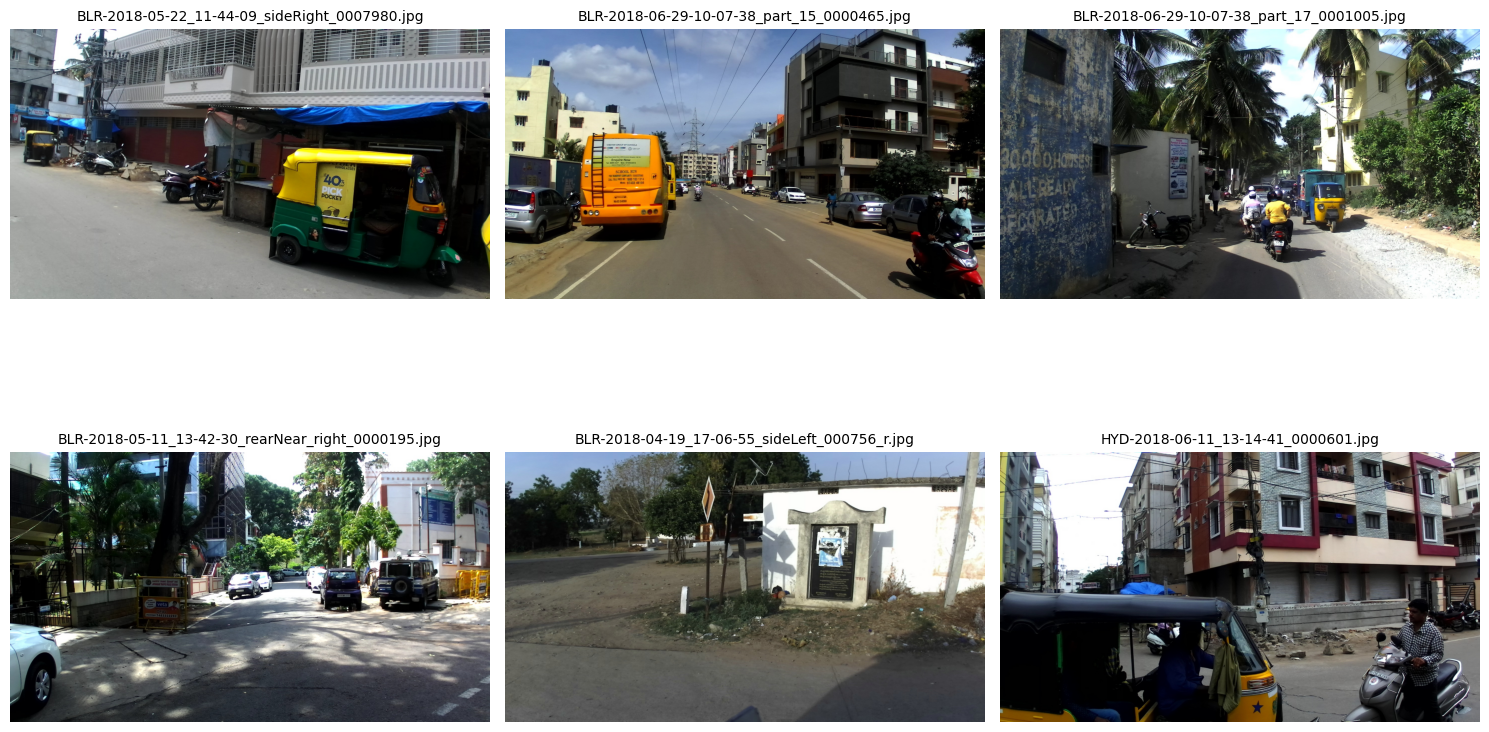

In [23]:
# ============================================================
# CELL 19: DISPLAY SAMPLE TRAINING IMAGES
# ============================================================

import random
import cv2
import matplotlib.pyplot as plt

sample_images = random.sample(
    train_images,
    min(6, len(train_images))
)

plt.figure(figsize=(15, 10))

for i, image_path in enumerate(sample_images):

    image = cv2.imread(str(image_path))

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    plt.subplot(2, 3, i + 1)

    plt.imshow(image)

    plt.title(
        image_path.name,
        fontsize=10
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [24]:
# ============================================================
# CELL 20: YOLO ANNOTATION VISUALIZATION FUNCTION
# ============================================================

def get_class_name(class_id):

    if isinstance(class_names, dict):

        return class_names.get(
            class_id,
            class_names.get(
                str(class_id),
                "Unknown"
            )
        )

    return class_names[class_id]


def show_annotation(image_path):

    image = cv2.imread(str(image_path))

    if image is None:
        return None

    image = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2RGB
    )

    height, width = image.shape[:2]

    # Corresponding YOLO label
    label_path = Path(image_path).with_suffix(".txt")

    if not label_path.exists():

        return image

    with open(label_path, "r") as file:

        lines = file.readlines()

    for line in lines:

        values = line.strip().split()

        if len(values) != 5:
            continue

        class_id, x, y, box_w, box_h = map(
            float,
            values
        )

        class_id = int(class_id)

        # YOLO normalized coordinates
        x1 = int(
            (x - box_w / 2) * width
        )

        y1 = int(
            (y - box_h / 2) * height
        )

        x2 = int(
            (x + box_w / 2) * width
        )

        y2 = int(
            (y + box_h / 2) * height
        )

        # Keep coordinates inside image
        x1 = max(0, min(x1, width - 1))
        y1 = max(0, min(y1, height - 1))
        x2 = max(0, min(x2, width - 1))
        y2 = max(0, min(y2, height - 1))

        # Draw bounding box
        cv2.rectangle(
            image,
            (x1, y1),
            (x2, y2),
            (255, 0, 0),
            2
        )

        label = get_class_name(class_id)

        # Draw class name
        cv2.putText(
            image,
            label,
            (x1, max(y1 - 8, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (255, 0, 0),
            2
        )

    return image

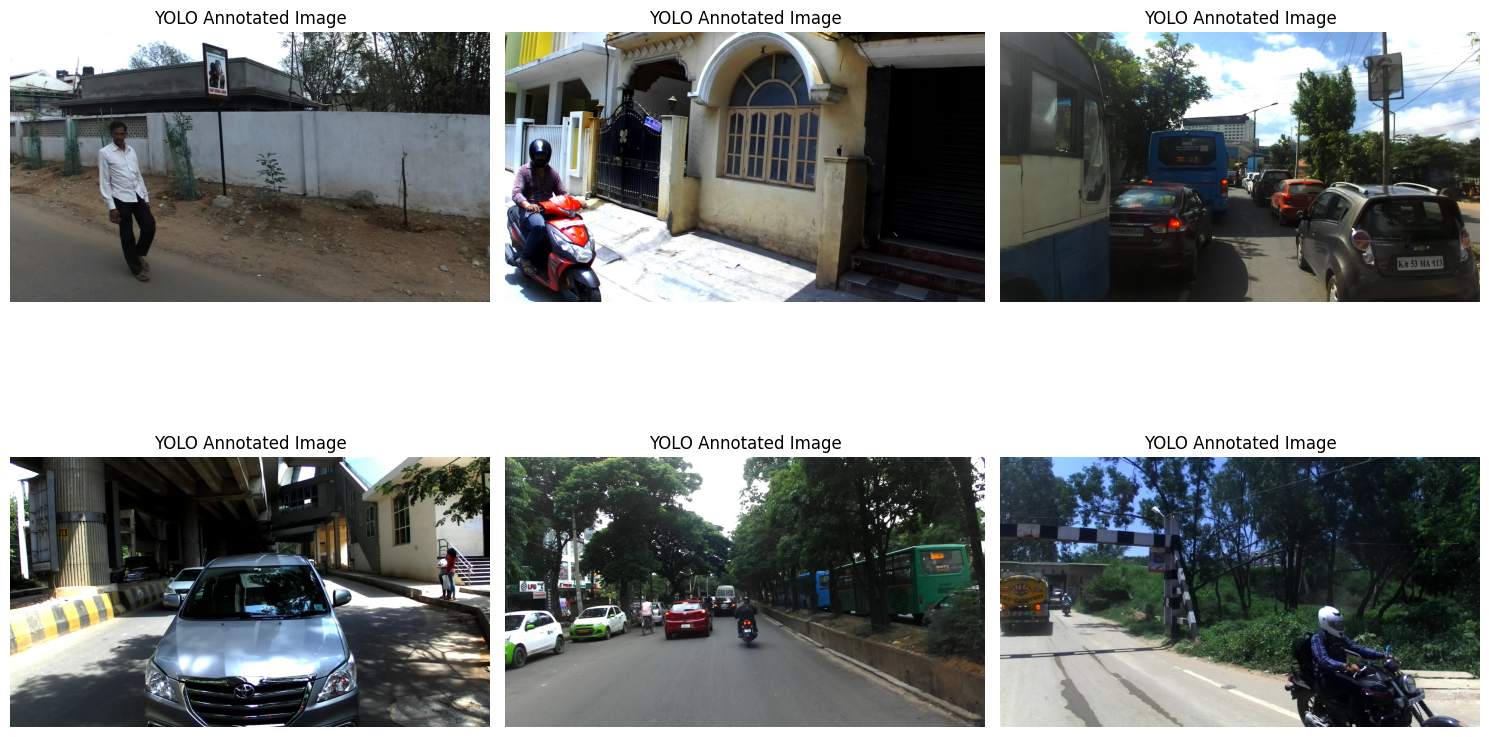

In [25]:
# ============================================================
# CELL 21: DISPLAY YOLO ANNOTATIONS
# ============================================================

sample_images = random.sample(
    train_images,
    min(6, len(train_images))
)

plt.figure(figsize=(15, 10))

for i, image_path in enumerate(sample_images):

    annotated_image = show_annotation(
        image_path
    )

    plt.subplot(2, 3, i + 1)

    plt.imshow(annotated_image)

    plt.title(
        "YOLO Annotated Image"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [26]:
# ============================================================
# CELL 22: IMPORT YOLO
# ============================================================

from ultralytics import YOLO

print("Ultralytics YOLO imported successfully!")

Ultralytics YOLO imported successfully!


In [27]:
# ============================================================
# CELL 23: FINAL GPU CHECK BEFORE TRAINING
# ============================================================

import torch

if not torch.cuda.is_available():

    raise RuntimeError(
        "❌ GPU is not available. "
        "Enable GPU from Runtime → Change runtime type."
    )

DEVICE = 0

print("🚀 GPU READY")
print(
    "GPU:",
    torch.cuda.get_device_name(0)
)

print(
    "CUDA:",
    torch.version.cuda
)

print(
    "GPU Memory:",
    round(
        torch.cuda.get_device_properties(0).total_memory
        / 1024**3,
        2
    ),
    "GB"
)

🚀 GPU READY
GPU: Tesla T4
CUDA: 12.8
GPU Memory: 14.56 GB


In [28]:
# ============================================================
# CELL 24: LOAD YOLO11N
# ============================================================

model = YOLO("yolo11n.pt")

print("✅ YOLO11n model loaded!")

✅ YOLO11n model loaded!


In [31]:
# ============================================================
# FAST YOLO11 TRAINING — GOOGLE COLAB T4 GPU
# ============================================================

from ultralytics import YOLO
import torch
import os

# Check GPU
if not torch.cuda.is_available():
    raise RuntimeError("GPU not available!")

print("GPU:", torch.cuda.get_device_name(0))

# Load pretrained YOLO11 Nano
model = YOLO("yolo11n.pt")

# Fast training configuration
results = model.train(

    data=FIXED_DATA_YAML,

    # Only use 10% of the dataset
    fraction=0.10,

    # Small number of epochs
    epochs=5,

    # Standard YOLO image size
    imgsz=640,

    # T4 GPU
    device=0,

    # Larger batch = faster training if memory allows
    batch=32,

    # Fewer workers to avoid Colab overhead
    workers=4,

    # Save results
    project="/content/Smart_Traffic_Monitoring/results",

    name="traffic_yolo11n_fast",

    # Stop if validation doesn't improve
    patience=3,

    # Generate plots
    plots=True,

    verbose=True
)

print("\n✅ FAST TRAINING COMPLETED!")

GPU: Tesla T4
Ultralytics 8.4.154 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Smart_Traffic_Monitoring/dataset/IDDDetectionsYOLODataset/fixed_data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=0.1, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, mu

In [33]:
from ultralytics import YOLO
import torch
import os

BEST_MODEL = "/content/Smart_Traffic_Monitoring/results/traffic_yolo11n_fast/weights/best.pt"

model = YOLO(BEST_MODEL)

print("✅ Trained YOLO model loaded!")
print("Model:", BEST_MODEL)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

✅ Trained YOLO model loaded!
Model: /content/Smart_Traffic_Monitoring/results/traffic_yolo11n_fast/weights/best.pt
GPU: Tesla T4


In [34]:
metrics = model.val(
    data=FIXED_DATA_YAML,
    imgsz=640,
    batch=32,
    device=0
)

print("\n===== FINAL MODEL METRICS =====")
print(f"Precision : {metrics.box.mp:.4f}")
print(f"Recall    : {metrics.box.mr:.4f}")
print(f"mAP@50    : {metrics.box.map50:.4f}")
print(f"mAP@50-95 : {metrics.box.map:.4f}")

Ultralytics 8.4.154 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 100 layers, 2,585,077 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2086.9±140.2 MB/s, size: 545.6 KB)
val: Scanning /content/Smart_Traffic_Monitoring/dataset/IDDDetectionsYOLODataset/val/labels.cache... 4196 images, 9 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4196/4196 880.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 132/132 1.8it/s 1:14
                   all       4196      49838      0.493      0.222      0.228       0.14
                animal        219        753      0.677     0.0876      0.134     0.0606
          autorickshaw       1436       3205      0.598      0.389      0.423      0.292
               bicycle        264        301      0.517      0.146      0.139      0.085
                   bus       1061       1794      0.634      0.388      0.418  

Test images found: 4197


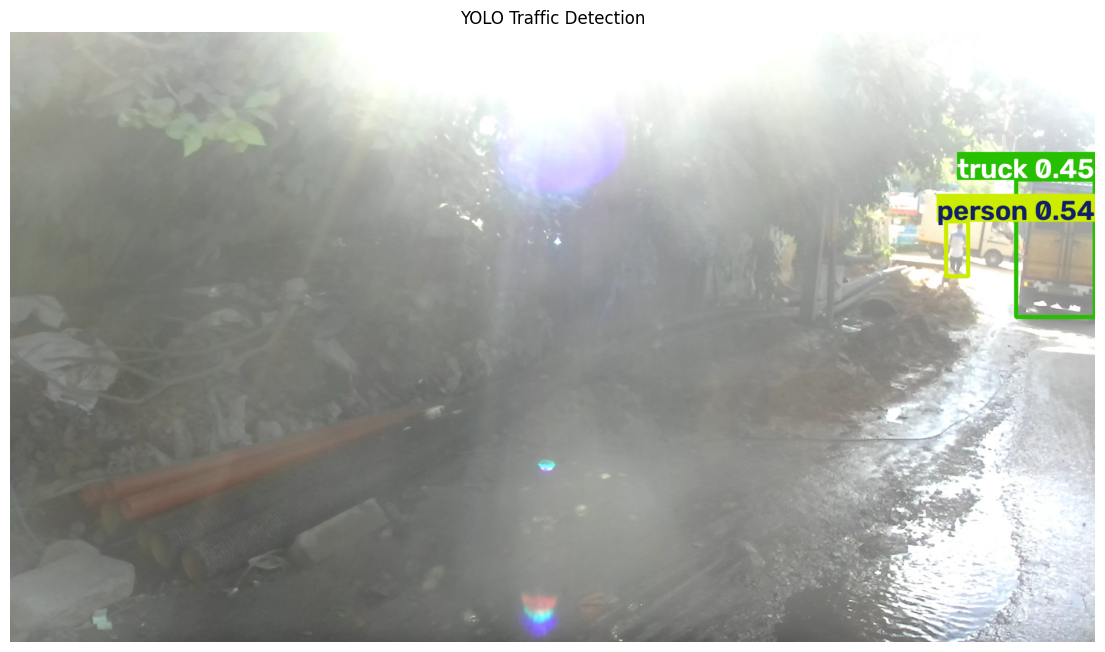

In [35]:
import glob
import matplotlib.pyplot as plt
import cv2

test_images = glob.glob(
    "/content/Smart_Traffic_Monitoring/dataset/IDDDetectionsYOLODataset/test/images/*"
)

print("Test images found:", len(test_images))

image_path = test_images[0]

results = model.predict(
    source=image_path,
    conf=0.25,
    imgsz=640,
    device=0,
    verbose=False
)

annotated = results[0].plot()

plt.figure(figsize=(14, 8))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("YOLO Traffic Detection")
plt.show()